In [1]:
import numpy as np 
from utilsforecast.plotting import plot_series
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from functools import partial
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from utilsforecast.evaluation import evaluate
from utilsforecast.feature_engineering import pipeline, trend
from utilsforecast.losses import rmse, mae, mape as _mape, mase, quantile_loss, mqloss
from statsforecast import StatsForecast
from statsforecast.models import (
    HistoricAverage,
    Naive,
    RandomWalkWithDrift,
    SeasonalNaive,
    SklearnModel,
)
from fpppy.models import LinearRegression

def mape(df, models, id_col = "unique_id", target_col = "y"):
    df_mape = _mape(df, models, id_col=id_col, target_col=target_col)
    df_mape.loc[:, df_mape.select_dtypes(include="number").columns] *= 100
    return df_mape

def quantile_score(df, models, q=0.5, id_col="unique_id", target_col="y"):
    df_qs = quantile_loss(df, models, q=q, id_col=id_col, target_col=target_col)
    df_qs.loc[:, df_qs.select_dtypes(include="number").columns] *= 2
    return df_qs

c:\Users\AFROCHEM\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# we will be the life cycle of any forcasting performed 
gdp_df=(
    pd.read_csv("data/global_economy.csv",parse_dates=["ds"])
    [["unique_id","ds","GDP","Population"]].assign(GDP=lambda x:x["GDP"].interpolate(),Population=lambda x:x['Population'].interpolate(),y=lambda x:x['GDP']/x['Population'],)
)

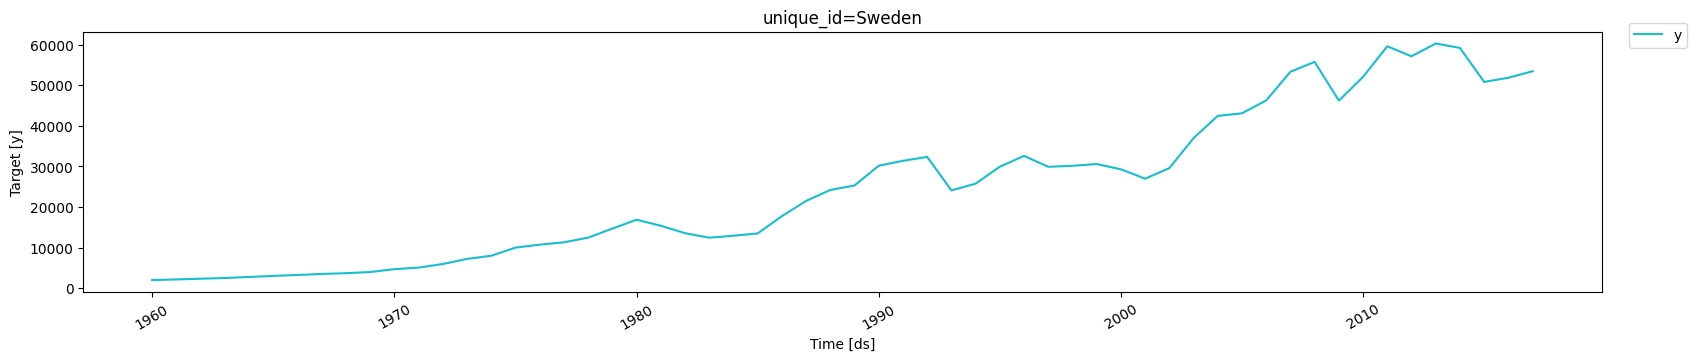

In [3]:
#plotting the GDP per capita of Sweden.
plot_series(gdp_df,ids=["Sweden"])

In [4]:
# training our model 
sweden_df=(gdp_df.loc[lambda x:x ['unique_id']=="Sweden"]
           [["unique_id","ds","y"]])
train_features,valid_features =pipeline(sweden_df,features=[trend],freq="Y",h=3)

trend_model=SklearnModel(LinearRegression())
sf=StatsForecast(models=[trend_model],freq="Y")
sf.fit(df=train_features)



c:\Users\AFROCHEM\AppData\Local\Programs\Python\Python312\Lib\site-packages\utilsforecast\processing.py:378: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
c:\Users\AFROCHEM\AppData\Local\Programs\Python\Python312\Lib\site-packages\utilsforecast\processing.py:434: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  freq = pd.tseries.frequencies.to_offset(freq)


StatsForecast(models=[LinearRegression])

c:\Users\AFROCHEM\AppData\Local\Programs\Python\Python312\Lib\site-packages\utilsforecast\processing.py:378: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
c:\Users\AFROCHEM\AppData\Local\Programs\Python\Python312\Lib\site-packages\utilsforecast\processing.py:434: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  freq = pd.tseries.frequencies.to_offset(freq)


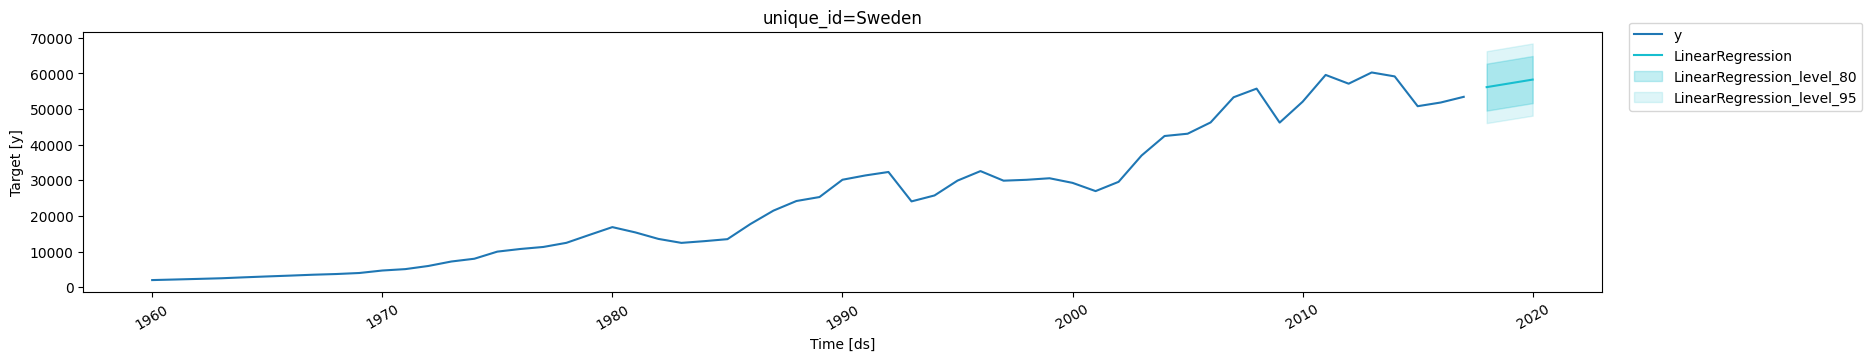

In [5]:
#producing Forcast
fcasts=sf.predict(h=3,X_df=valid_features)
model=sf.fitted_[0][0].model_['model']
fcasts=model.add_prediction_intervals(fcasts,valid_features.rename(columns={"trend":"x1"}))

#visualizing the result
plot_series(sweden_df,fcasts,ids=["Sweden"],level=[80,95])

In [6]:
production_df=pd.read_csv("data/aus_production_formatted.csv",parse_dates=['ds'])
bricks_df=(production_df.loc[lambda x:((x["unique_id"]=="Bricks")&(x['ds'].between("1970","2004-12")))].dropna())


In [7]:
#BaseLine Models before choosing a model to compare with

avg_method=HistoricAverage()
sf=StatsForecast(models=[avg_method],freq="Q")


[]

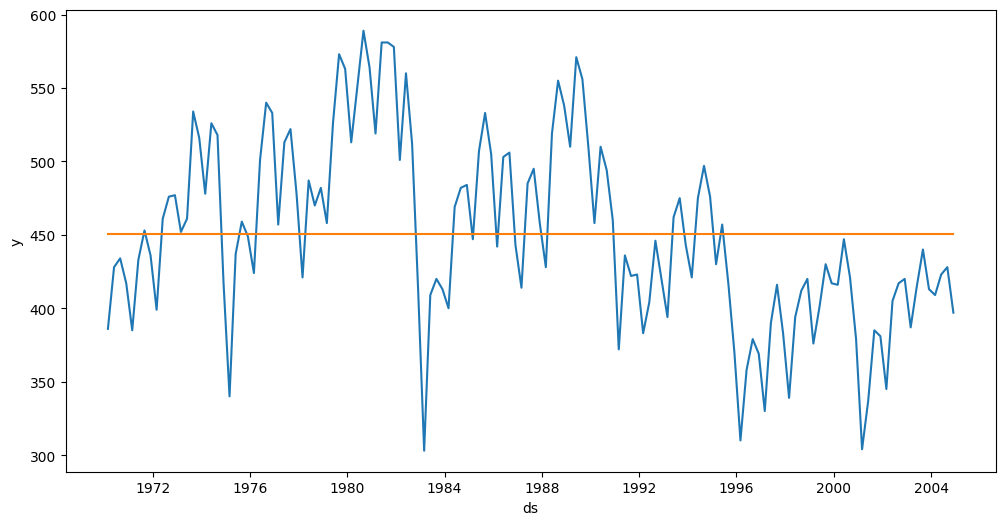

In [8]:
#plotting the Baseline model
y_mean=bricks_df['y'].mean()
fig,ax=plt.subplots(figsize=(12,6))
sns.lineplot(data=bricks_df,x="ds",y="y",ax=ax)
sns.lineplot(data=bricks_df,x='ds',y=y_mean,ax=ax)
plt.plot()

c:\Users\AFROCHEM\AppData\Local\Programs\Python\Python312\Lib\site-packages\utilsforecast\processing.py:378: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
c:\Users\AFROCHEM\AppData\Local\Programs\Python\Python312\Lib\site-packages\utilsforecast\processing.py:434: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  freq = pd.tseries.frequencies.to_offset(freq)


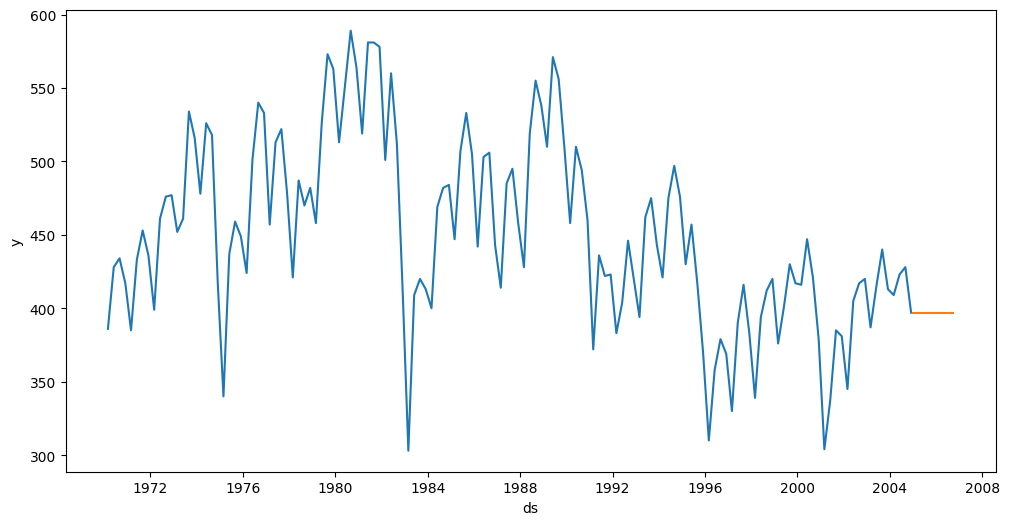

In [9]:
#Naive Method (we simply set all forcasts to be the value of the last observation)
naive_method=Naive()
sf=StatsForecast(models=[naive_method],freq="Q")
forecast_df=sf.forecast(df=bricks_df,h=8)

fig,ax=plt.subplots(figsize=(12,6))
sns.lineplot(data=bricks_df,x="ds",y="y")
sns.lineplot(data=forecast_df,x="ds",y="Naive")


plt.show()


c:\Users\AFROCHEM\AppData\Local\Programs\Python\Python312\Lib\site-packages\utilsforecast\processing.py:378: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
c:\Users\AFROCHEM\AppData\Local\Programs\Python\Python312\Lib\site-packages\utilsforecast\processing.py:434: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  freq = pd.tseries.frequencies.to_offset(freq)


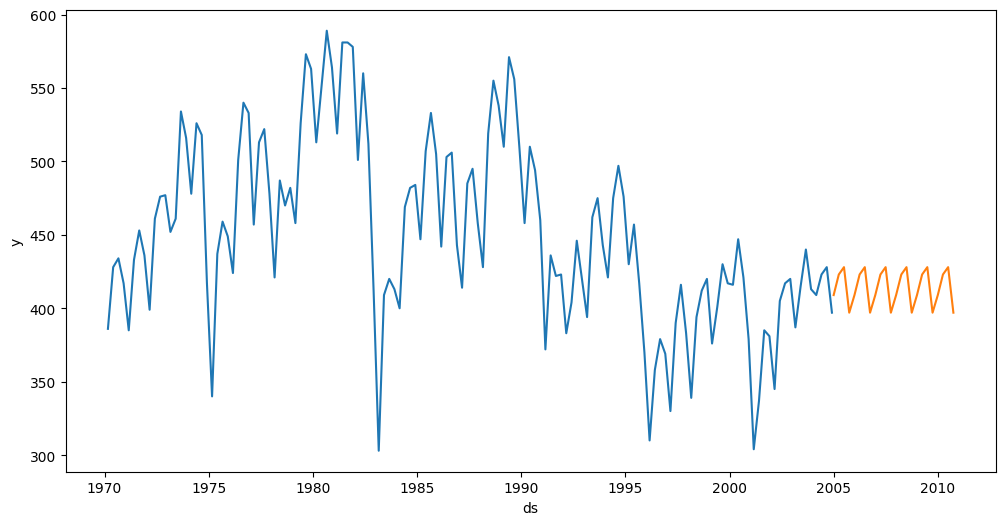

In [10]:
#Seasonal Naive method yt+h = yt+h-m(k+1)
#Seasonal Naive method(we set each forcast to be equal to the last observation from the same season)
seasonal_naive_method=SeasonalNaive(4)# 4 because of Quarterly data
sf=StatsForecast(models=[seasonal_naive_method],freq="Q") 
seasonal_sf_df=sf.forecast(df=bricks_df,h=24)
fig,ax=plt.subplots(figsize=(12,6))
sns.lineplot(data=bricks_df,x="ds",y="y")
sns.lineplot(data=seasonal_sf_df,x="ds",y="SeasonalNaive")


plt.show()


c:\Users\AFROCHEM\AppData\Local\Programs\Python\Python312\Lib\site-packages\utilsforecast\processing.py:378: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
c:\Users\AFROCHEM\AppData\Local\Programs\Python\Python312\Lib\site-packages\utilsforecast\processing.py:434: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  freq = pd.tseries.frequencies.to_offset(freq)


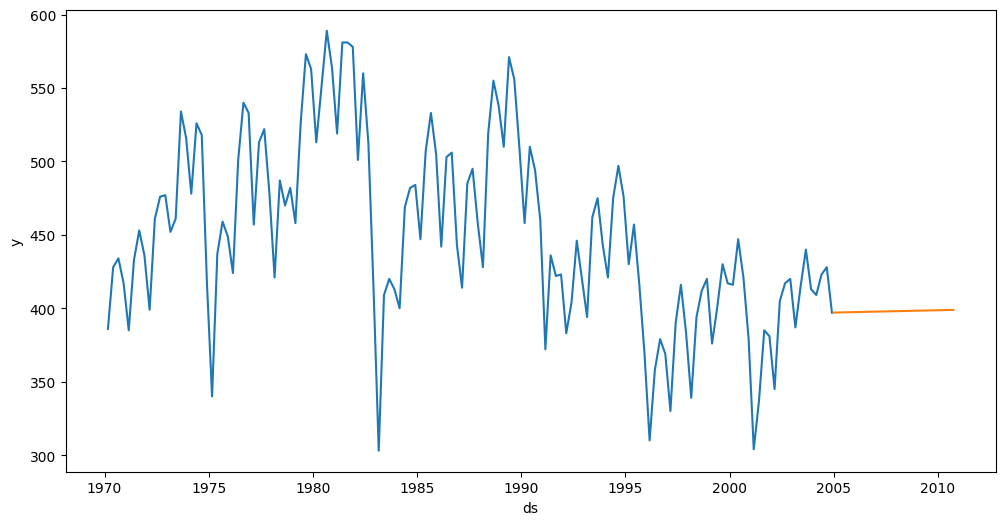

In [11]:
#Drift Method (allows forecasts to increase/decrease over time where the amount of change over time (called drift))
#Given by Y(T+h)= YT+ h/T-1 *yT-y1)
drift_method=RandomWalkWithDrift()
sf=StatsForecast(models=[drift_method],freq="Q")
drift_sf_df=sf.forecast(df=bricks_df,h=24)

fig,ax=plt.subplots(figsize=(12,6))
sns.lineplot(data=bricks_df,x="ds",y="y")
sns.lineplot(data=drift_sf_df,x="ds",y="RWD")


plt.show()


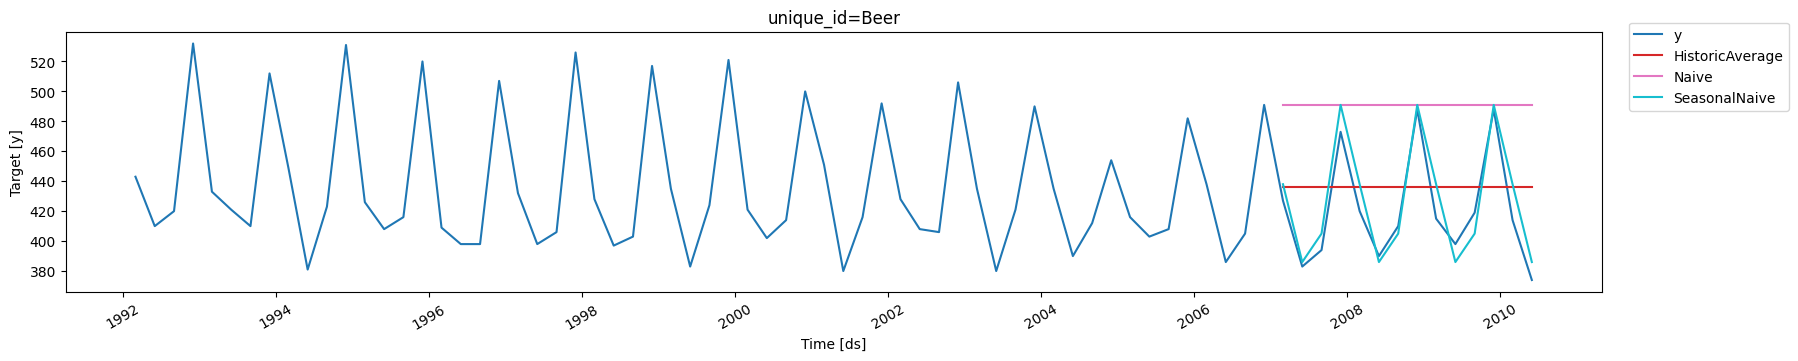

In [12]:
#benchmarks to compare
beers_df=production_df.loc[lambda x:(x['unique_id']=="Beer")&(x["ds"]>="1992")]
train=beers_df.loc[lambda x:x["ds"]<"2007"]
test=beers_df.loc[lambda x:x["ds"]>="2007"]

avg_method=HistoricAverage()
naive_method=Naive()
seasonal_method=SeasonalNaive(4)
sf=StatsForecast(models=[avg_method,naive_method,seasonal_method],freq=pd.offsets.QuarterBegin(1),)

sf.fit(train)
fcasts=sf.predict(h=14).assign(y=test['y'].to_numpy())

plot_series(train, fcasts)

c:\Users\AFROCHEM\AppData\Local\Programs\Python\Python312\Lib\site-packages\utilsforecast\processing.py:378: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
c:\Users\AFROCHEM\AppData\Local\Programs\Python\Python312\Lib\site-packages\utilsforecast\processing.py:434: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  freq = pd.tseries.frequencies.to_offset(freq)


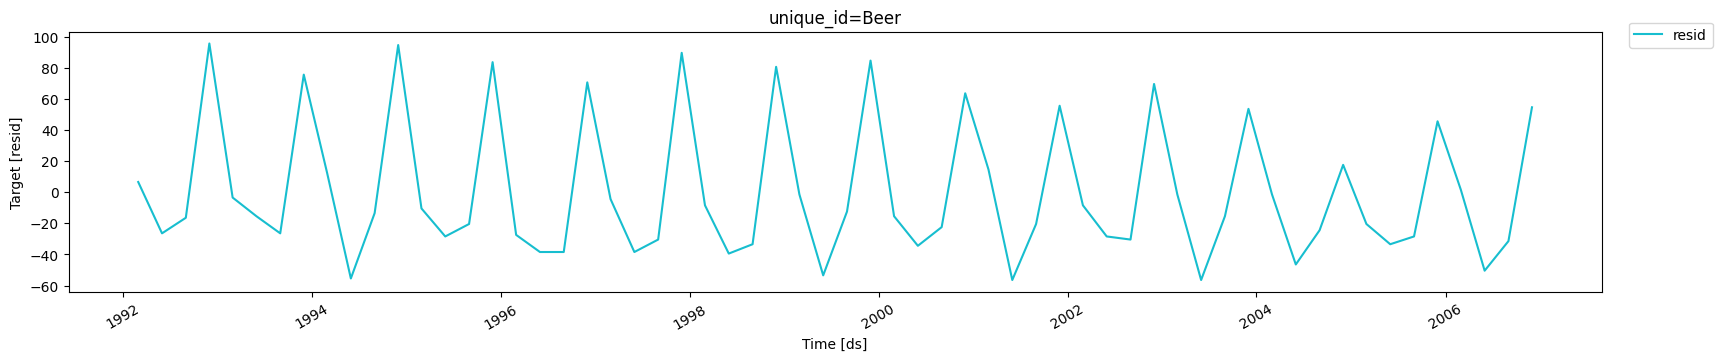

In [15]:
#understanding fitted and residuals
train=beers_df.loc[lambda x:(x['ds']<"2007")]
test=beers_df.loc[lambda x:(x['ds']>="2007")]

avg_method=HistoricAverage()
sf=StatsForecast(models=[avg_method],freq="Q")
sf.forecast(h=14,df=train,fitted=True)
fitted_values=sf.forecast_fitted_values()
df=train.assign(fitted=fitted_values['HistoricAverage'].to_numpy(),
                resid=lambda x:x['y']-x['fitted'],
                innov=lambda x:x['y']-x['fitted'],)
df.head()
plot_series(df=df,target_col="resid")

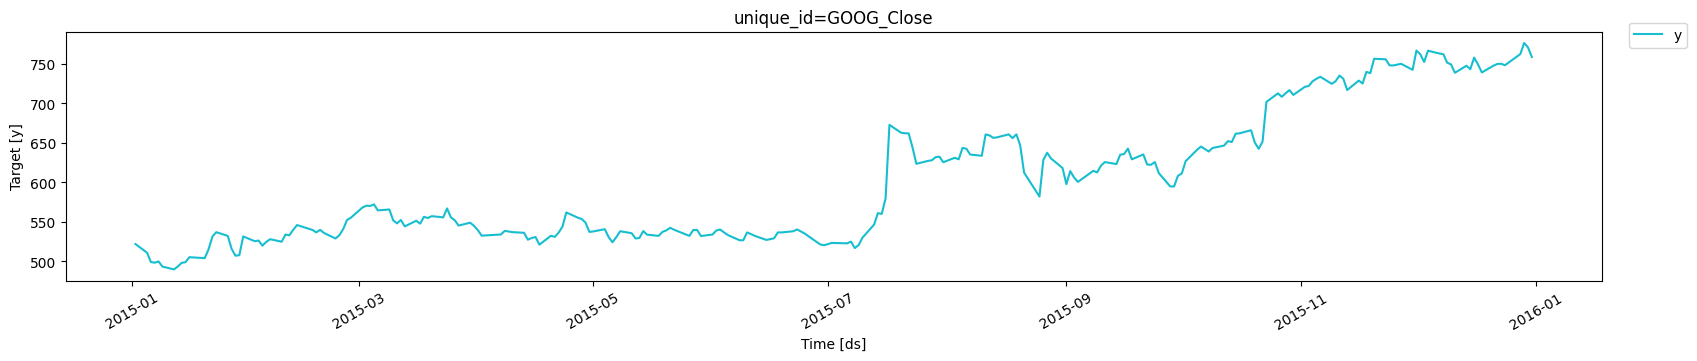

In [24]:
#Forcasting Google daily closing Stock prices
df=pd.read_csv("data/gafa_stock.csv",parse_dates=['ds'])
train=df[(df['unique_id']=="GOOG_Close") & (df['ds'].dt.year==2015)]

plot_series(train)

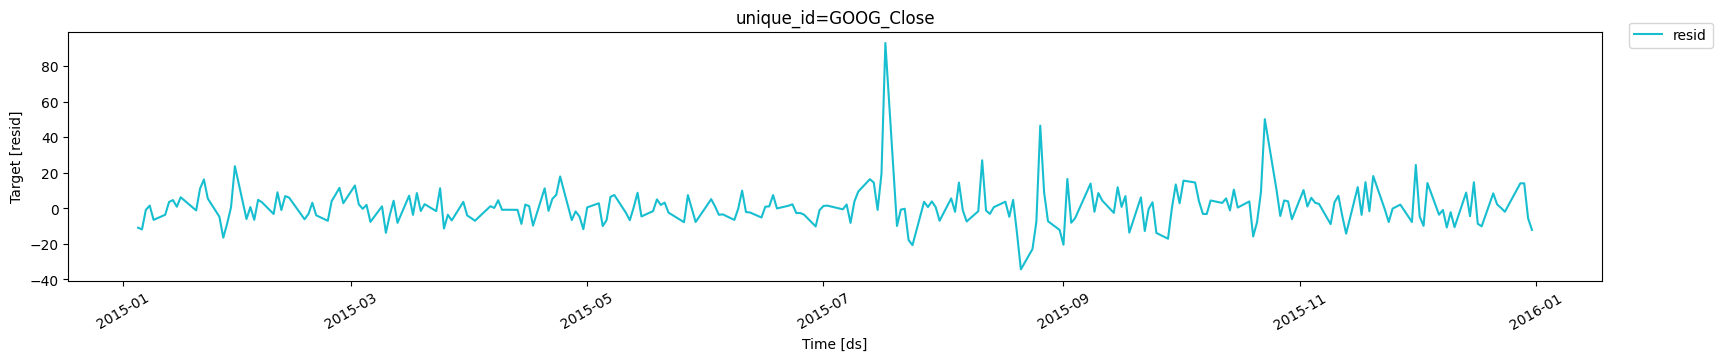

In [ ]:
# the mean is centered around zero
plt.rcParams["figure.figsize"]=(7,3.6)
resid=train.assign(resid=lambda x:x['y'].diff())
plot_series(resid,target_col="resid")

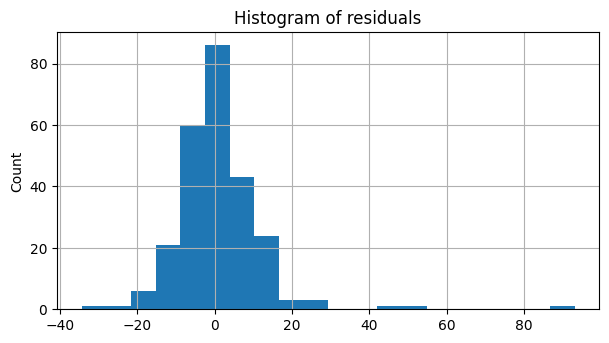

In [ ]:
#looks like a normal distribution
ax=resid["resid"].hist(bins=20)
ax.set(title="Histogram of residuals",ylabel="Count")
plt.show()

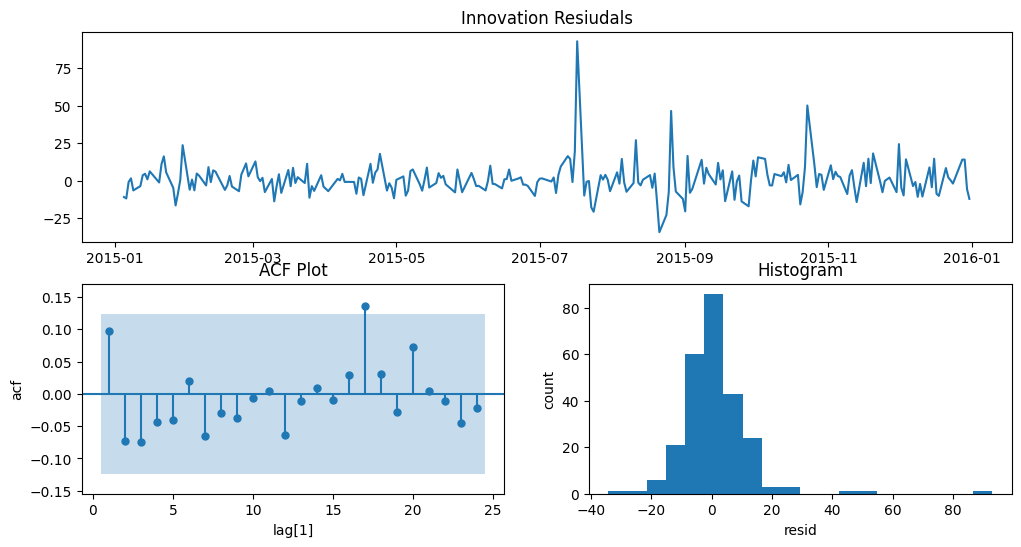

In [29]:
# To Sum all this up we use a func called plot
def plot_diagnostics(data):
    _,axes=plt.subplot_mosaic([["resid","resid"],["acf","hist"]])
    ax=axes["resid"]
    ax.plot(data["ds"],data["resid"])
    ax.set(title="Innovation Resiudals")
    ax=axes["acf"]
    plot_acf(data['resid'].dropna(),zero=False,bartlett_confint=False,auto_ylims=True,ax=ax)
    ax.set(title="ACF Plot",xlabel="lag[1]",ylabel="acf")
    ax=axes["hist"]
    ax.hist(data["resid"],bins=20)
    ax.set(title="Histogram",xlabel="resid",ylabel="count")
plt.rcParams['figure.figsize']=(12,6)
plot_diagnostics(resid)

In [32]:
#test of autocorrelation
resid_test=acorr_ljungbox(resid["resid"].dropna(),boxpierce=True)
resid_test.head()

,lb_stat,lb_pvalue,bp_stat,bp_pvalue
1,2.417335,0.119999,2.388671,0.122217
2,3.761022,0.152512,3.711114,0.156366
3,5.192966,0.158200,5.114758,0.163584
4,5.674577,0.224805,5.584948,0.232363
5,6.084444,0.298089,5.983475,0.307830


In [33]:
#Alternate way to forcast the Google Closing price
drift_method=RandomWalkWithDrift()
sf=StatsForecast(models=[drift_method],freq="B")
sf.fit(train)

fcast=sf.forecast(h=10,df=train,fitted=True)
insample=sf.forecast_fitted_values().assign(resid=lambda x:x["y"]-x["RWD"])
insample.head()

,unique_id,ds,y,RWD,resid
0,GOOG_Close,2015-01-02,521.937744,NaN,NaN
1,GOOG_Close,2015-01-05,511.057617,522.881737,-11.824120
2,GOOG_Close,2015-01-06,499.212799,512.001610,-12.788811
3,GOOG_Close,2015-01-07,498.357513,500.156792,-1.799279
4,GOOG_Close,2015-01-08,499.928864,499.301506,0.627358


In [34]:
resid_test=acorr_ljungbox(insample["resid"].dropna(),boxpierce=True)
resid_test

,lb_stat,lb_pvalue,bp_stat,bp_pvalue
1,2.417335,0.119999,2.388671,0.122217
2,3.761022,0.152512,3.711114,0.156366
3,5.192966,0.158200,5.114758,0.163584
4,5.674577,0.224805,5.584948,0.232363
5,6.084444,0.298089,5.983475,0.307830
6,6.194822,0.401724,6.090363,0.413144
7,7.302747,0.398053,7.158875,0.412528
8,7.524630,0.481225,7.371988,0.497080
9,7.901719,0.544080,7.732682,0.561294
10,7.914143,0.637223,7.744517,0.653776


In [38]:
#Prediction interval for a Forecast done in a muti-step(h>1)

df=pd.read_csv("data/gafa_stock.csv",parse_dates=['ds'])
train=df.loc[lambda x:(x["ds"].dt.year==2015)&(x['unique_id']=="GOOG_Close")].copy()
train["ds"]=np.arange(len(train))
naive_method=Naive()
sf=StatsForecast(models=[naive_method],freq=1)
fcasts=sf.forecast(df=train,h=10,level=[80,95])
fcasts

,unique_id,ds,Naive,Naive-lo-80,Naive-lo-95,Naive-hi-80,Naive-hi-95
0,GOOG_Close,252,758.880005,744.539977,736.948825,773.220033,780.811185
1,GOOG_Close,253,758.880005,738.600143,727.864632,779.159867,789.895378
2,GOOG_Close,254,758.880005,734.042348,720.894087,783.717662,796.865923
3,GOOG_Close,255,758.880005,730.199949,715.017645,787.560061,802.742365
4,GOOG_Close,256,758.880005,726.814728,709.840395,790.945282,807.919615
5,GOOG_Close,257,758.880005,723.754254,705.159804,794.005756,812.600206
6,GOOG_Close,258,758.880005,720.939857,700.855556,796.820153,816.904454
7,GOOG_Close,259,758.880005,718.320281,696.849260,799.439729,820.910750
8,GOOG_Close,260,758.880005,715.859921,693.086464,801.900089,824.673546
9,GOOG_Close,261,758.880005,713.532855,689.527524,804.227155,828.232486


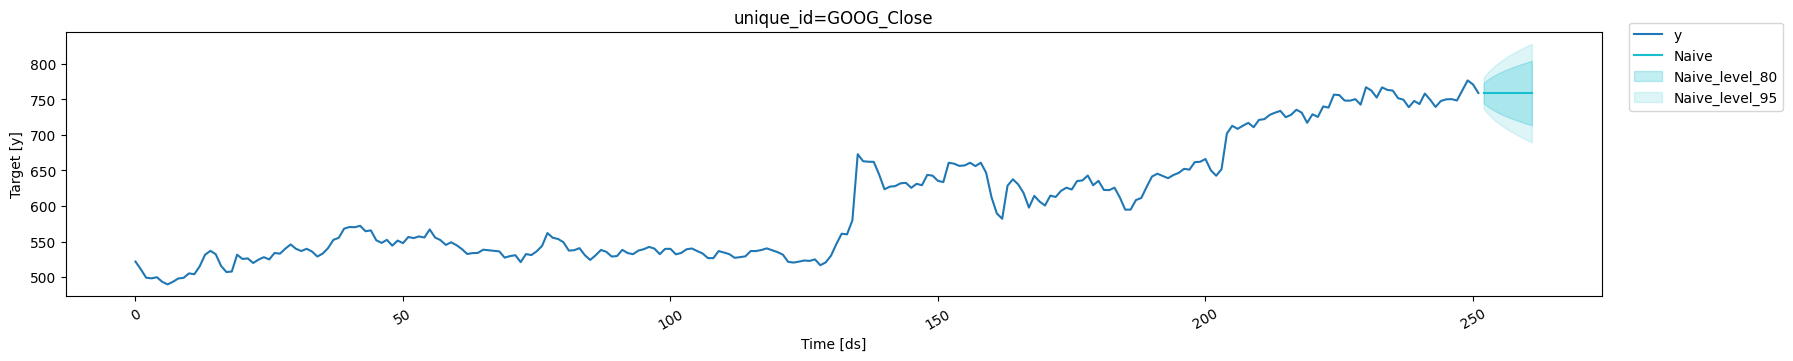

In [39]:
#plotting intervals
plt.rcParams["figure.figsize"]=(7,4)
plot_series(train,fcasts,level=[80,95])